In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Data Preparation and Cleaning
I am importing only the necessary features:
- Variables required to calculate the star's absolute magnitude:
- - Vmag – apparent magnitude.
- - Plx – parallax (in milliarcseconds).
- Variables describing stellar color (color indices):
- - B-V – brightness difference between the 440nm (Blue) and 550nm (Green/Visual) bands.
- - V-I – brightness difference between the 550nm (Green/Visual) and approx. 800nm (Infrared) bands.
- - Alternative color indices (calculated from Tycho bands):
- - - BTmag – magnitude in the 420nm band (Tycho Blue).
- - - VTmag – magnitude in the 530nm band (Tycho Visual).
Note: These will be used to calculate a secondary B-V index as a comparison.
- SpType – spectral type (target variable).

In [2]:
cols = ['Vmag', 'Plx', 'B-V', 'V-I', 'BTmag', 'VTmag', 'SpType']
df = pd.read_csv("hipparcos-voidmain.csv", usecols=cols)

Firstly, we want rid stars with non-positive value of parallax. The parallax is seeming movement while changing point of view of nearer object against the background of further objects. The simplest way to see parallax is stretching your finger out in front of you, closing one eye, and then opening that eye and closing another one. The finger "moves" against the background, and that move is greater as your finger is closer to your eyes.

In astronomy the parallax is measuring in the following way. Firstly, the photo of star is taking, and then must pass half a year to taking a second photo. Because the Earth moves around the Sun, we change the point of view (similary when we changed the looking eye). The stars which are closer to us, "move" against the background of further stars or galaxies. Because the Stars are much further away than the diameter of the Earth's orbit, this motion is very subtle. In this dataset one used miliseconds of arc. 1 second of arc is 1/60 of 1 minute of arc, which is 1/60 of 1 degree of arc. So 1 second of arc is 1/1 296 000 of full rotation. 1 milisecond of arc is 1/1000 of 1 second of arc. For comparision, people can distinguish objects seperated by at least 1 minute of arc.

So, the parallax cannot be negative. Zero parallax can mean that the object is very, very far away, or it can be some error. And that is why we want delete non-positive parralaxes.

In [3]:
df = df[df["Plx"]>0]

Looking for NA values

In [4]:
print(len(df))

df.isna().any(axis=1).sum()

113710


4506

We can see, that we have only about 4500 rows with NaN, while the total number of rows is above 110,000. We'll simply drop NaN values.

In [5]:
df.dropna(inplace = True)

Then we'll calculate the absolute brightness of the star based on the value of parallax and observed brightness. The absolute brightness is defined as brightness of the star from distance 10 parsecs (or about 31 light years). It is something like standarized brightness of the star (not depending from distance to the Earth). The formula for absolute brightness is:
$$M = m + 5 - 5 \log_{10}(d)$$
where:
- $M$ - absolute magnitude (brightness) of the star,
- $m$ - observed magnitude of the star, in dataset denote as `Vmag`,
- $d$ - distance to the star in parsecs. It can be calculated from the formula:
$$d = \frac{1000}{plx}$$
  where $d$ is observed parallax in miliseconds of arc, denote as `Plx`.

In [6]:
df["dist"] = 1000/df["Plx"]
df["AbsMag"] = df["Vmag"] + 5 - 5*np.log10(df["dist"])

We'll calculate the difference in magnitude of BT and VT band, analogously as it is in B-V and V-I variables. The color can be describe as difference in magnitude in appropriate bands. For example, if difference in brightness between blue band and green band is highly positive, we can conclude, that star is blue (is much more bright in blue than in green), and if that difference is small, the star have similar brightness in this two colors (probably is bright in red or infrared).

In [7]:
df["BT-VT"] = df["BTmag"] - df["VTmag"]

The next step is cleaning the `SpType` i.e. spectral type of the star. We want get rid deep levels of classification, and keep only the first letter.

In [8]:
df["TargetClass"] = df["SpType"].str[0]

print(df["TargetClass"].value_counts())

TargetClass
K    30307
F    24927
G    22011
A    18134
B     9512
M     3820
O      184
C      114
R       51
s       46
W       38
N       31
S       14
D       12
k        1
(        1
p        1
Name: count, dtype: int64


We only are interested in the stars from the main sequence i.e. the types: O, B, A, F, G, K, and M. We can see, that the number of other types is small, so they are useless for us (Note, that the number of O-type stars is also very small, and it can be challenging in further part of project, however they are from main sequence and I want to take into acount them)

In [9]:
main_sequence = ["O", "B", "A", "F", "G", "K", "M"]

df = df[df["TargetClass"].isin(main_sequence)]

It looks like all steps with data preprocesing has done. Let's see some plots and statistics.

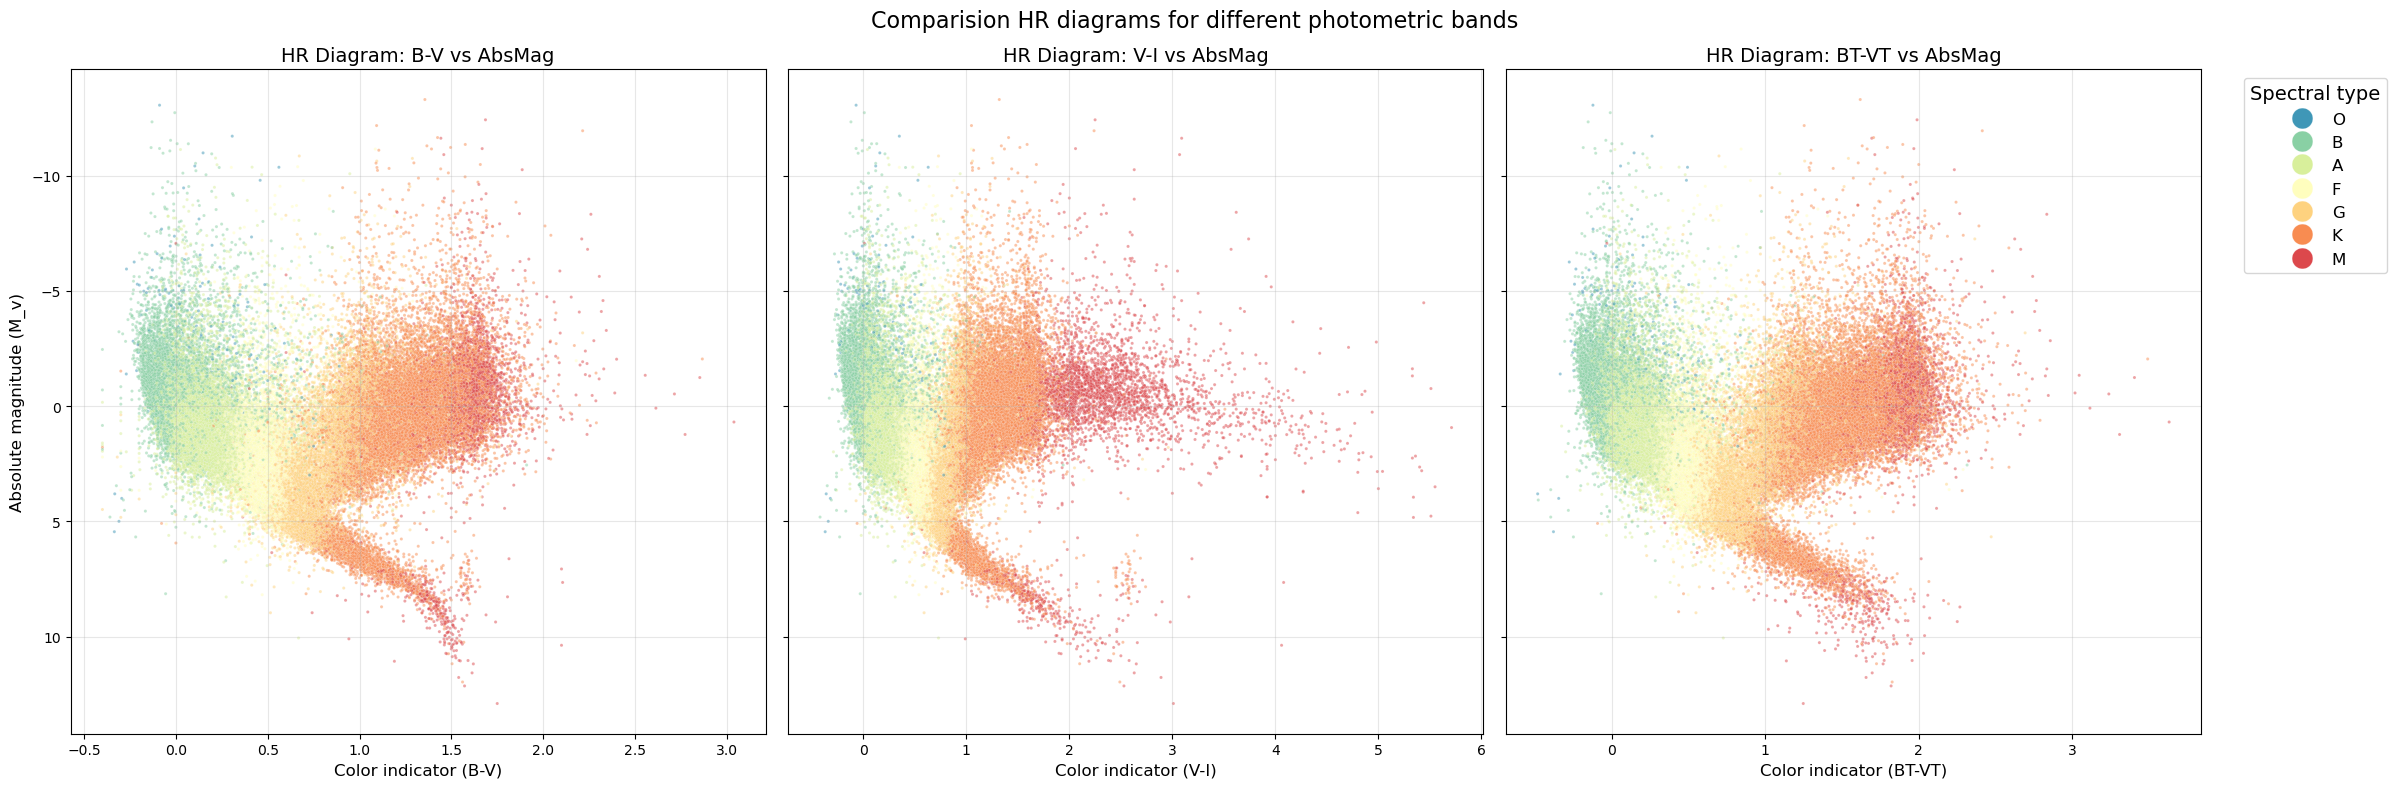

In [10]:
#Code below was mainly generated by AI

color_indices = ['B-V', 'V-I', 'BT-VT']

fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

for ax, col in zip(axes, color_indices):
    sns.scatterplot(
        data=df, 
        x=col, 
        y='AbsMag', 
        hue='TargetClass', 
        hue_order=['O', 'B', 'A', 'F', 'G', 'K', 'M'], 
        s=5,           
        alpha=0.5,     
        palette='Spectral_r', 
        ax=ax,
        legend='full' if col == 'BT-VT' else False
    )
    
    ax.invert_yaxis()
    ax.set_title(f"HR Diagram: {col} vs AbsMag", fontsize=14)
    ax.set_xlabel(f"Color indicator ({col})", fontsize=12)
    ax.grid(True, alpha=0.3)
    
# --- POPRAWA LEGENDY  ---
    if col == 'BT-VT':
        legend = ax.legend(title='Spectral type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        legend.get_title().set_fontsize(14)
        
        for handle in legend.legend_handles:
            try:
                handle.set_sizes([150]) 
            except AttributeError:
                handle.set_markersize(15)
                
            handle.set_alpha(1.0)

axes[0].set_ylabel("Absolute magnitude (M_v)", fontsize=12)

plt.suptitle("Comparision HR diagrams for different photometric bands", fontsize=16)
plt.tight_layout()
plt.show()

In these plots we can see, that truly we have similar shapes for what is known as Hertzsprung–Russell diagram. We can see, that B-V and BT-VT indicators give similar, but not exactly the same results. This two bands gives a bit diffrent results for dark stars (lower part of the diagram). We can also see, that V-I indicator stretches red stars (i.e. M-category), so it can be better in recognition this type. In the clasical HR diagram, in the top right part, there is an "island" of giant stars, and wavy line goes from top left to the bottom right. In our data this island is connected with that line, created Y shape (or North America shape). 

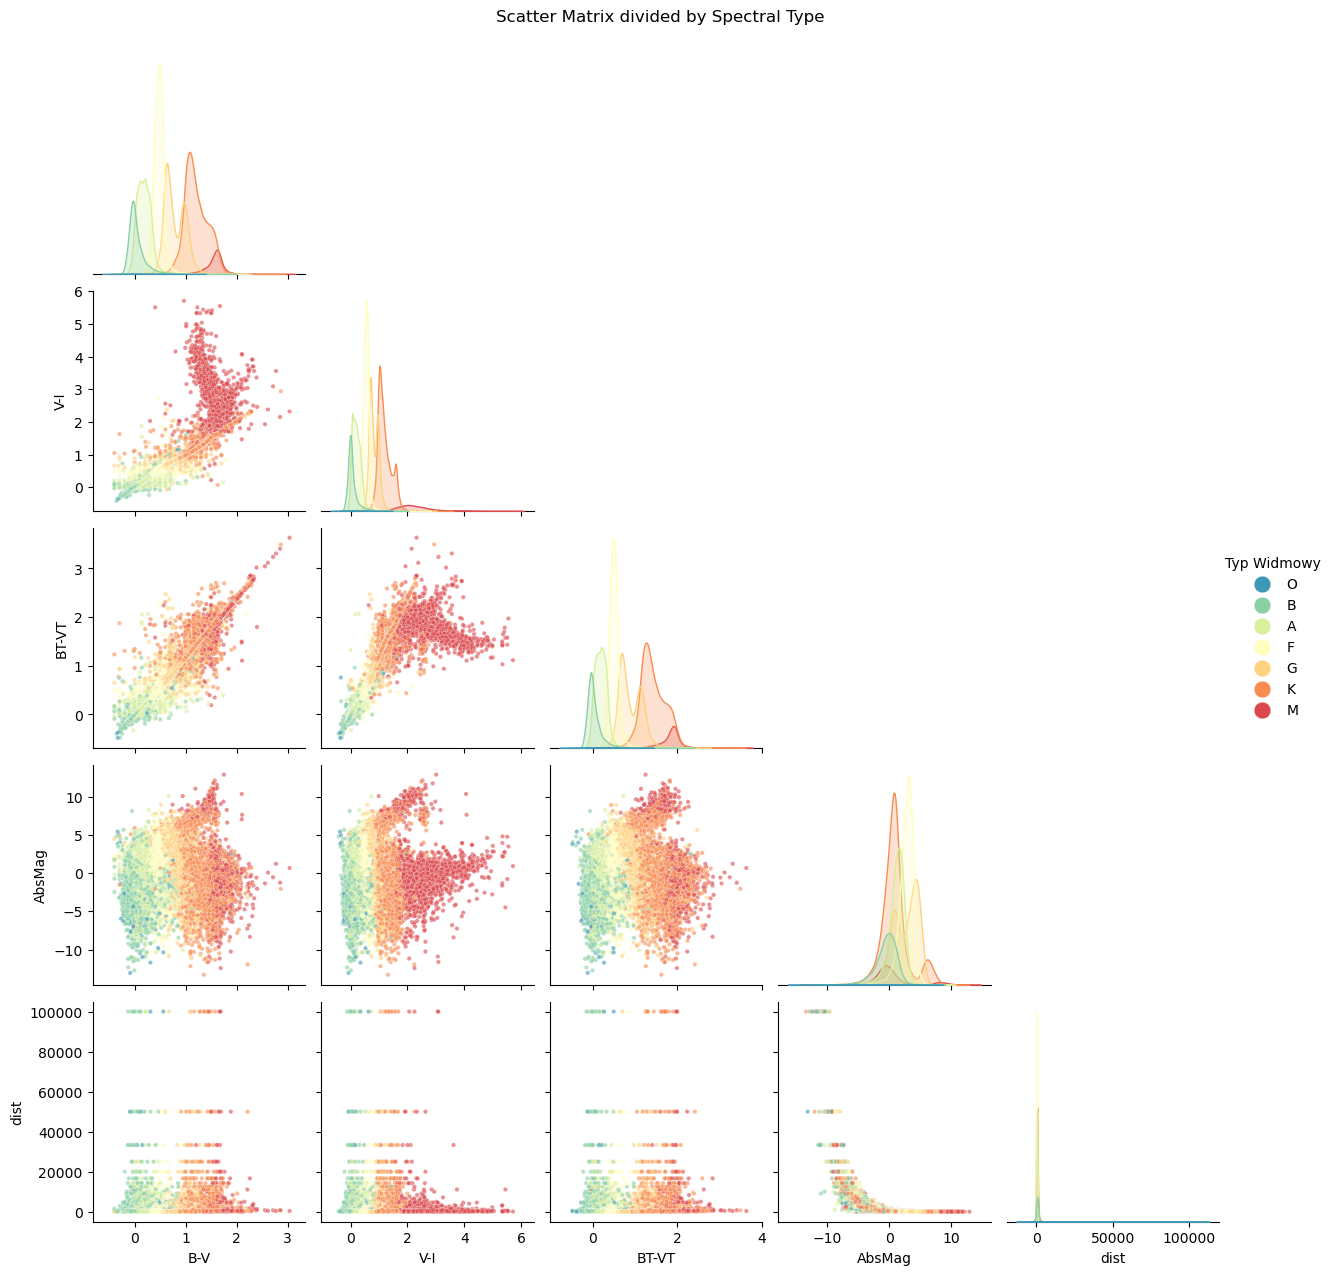

In [11]:
g = sns.pairplot(
    df, 
    vars=["B-V", "V-I", "BT-VT", "AbsMag", "dist"], 
    hue='TargetClass', 
    hue_order=['O', 'B', 'A', 'F', 'G', 'K', 'M'],
    palette='Spectral_r',
    plot_kws={'alpha': 0.6, 's': 10}, # Przezroczystość i rozmiar punktów
    corner=True 
)

legend = g._legend

if legend:
    legend.set_title("Typ Widmowy")
    
    # Używamy właściwej nazwy atrybutu: legend_handles
    for handle in legend.legend_handles: 
        
        # Ustawiamy pełną widoczność
        handle.set_alpha(1.0)
        
        # Bezpieczne ustawianie rozmiaru (działa dla obu typów obiektów)
        try:
            handle.set_sizes([150])      # Dla PathCollection (kropki scattera)
        except AttributeError:
            handle.set_markersize(12)    # Dla Line2D (gdyby matplotlib tak to zinterpretował)

# Tytuł (trzeba przesunąć lekko w górę)
plt.suptitle("Scatter Matrix divided by Spectral Type", y=1.02)
plt.show()

Let's analyse plots. Firstly we can see, that for red stars B-V and BT-VT are almost ideal linear correlated, so we can expect, that for red stars these two indicators will give almost the same results. For more blue stars there is also visible correlation, however it is more blured. We can also see, that for blue stars V-I is correlated with B-V and BT-VT, but for red stars there is no visible correlation. Third row is filled with HR diagrams which was described above (but they are flipped). In the fourth row we can see plots with distances. For all plots it is a bit disturbing seeing, that far distances are "discretised". Maybe for far stars, the parallax was so small, it was recorded only in few levels (e.g. 0.01, 0.02, 0.03 and so on), and we can see that levels here. Maybe we should consider deleting them? Beside this, the diagrams looks like it was expected. Stars with different colors are distributed equally, excluding very red and blue stars, which have so weak brightness in considered bands, it is possible to detect only near ones. Whereas Absolute Magnitude is directly dependent with distance by logharithm of inverse of distance, what can be saw at diagram. Histograms also doesn't show anything disturbing. Colors indicators are distributed almost equally (differences in Spectral Types comes from different numbers of stars in each type), excluding VI, but it is excepted behavior. Absolute Magnitude is also distibuted nicely. We can see, that very blue stars are very bright, while very red stars are dark. However it is also excepted, because, the blue stars are mostly very hot and bright, while red stars are cold and dark. In the distance histogram, we can see, that there is a quite small number very far stars, so it gives us another reason to delete them.

So let's try delete them! From the information about Hiparcos satelite (from which the analysed measurments came from), we know, that only stars closer to 1000 parsecs are measurment properly. Further distances we must get rid.

In [10]:
print(len(df[df["dist"]>=1000]))

df = df[df["dist"]<1000]

6127


Let's see how spectral types are distributed and how plots looks like

TargetClass
K    28068
F    24514
G    21343
A    17329
B     8155
M     3255
O      104
Name: count, dtype: int64


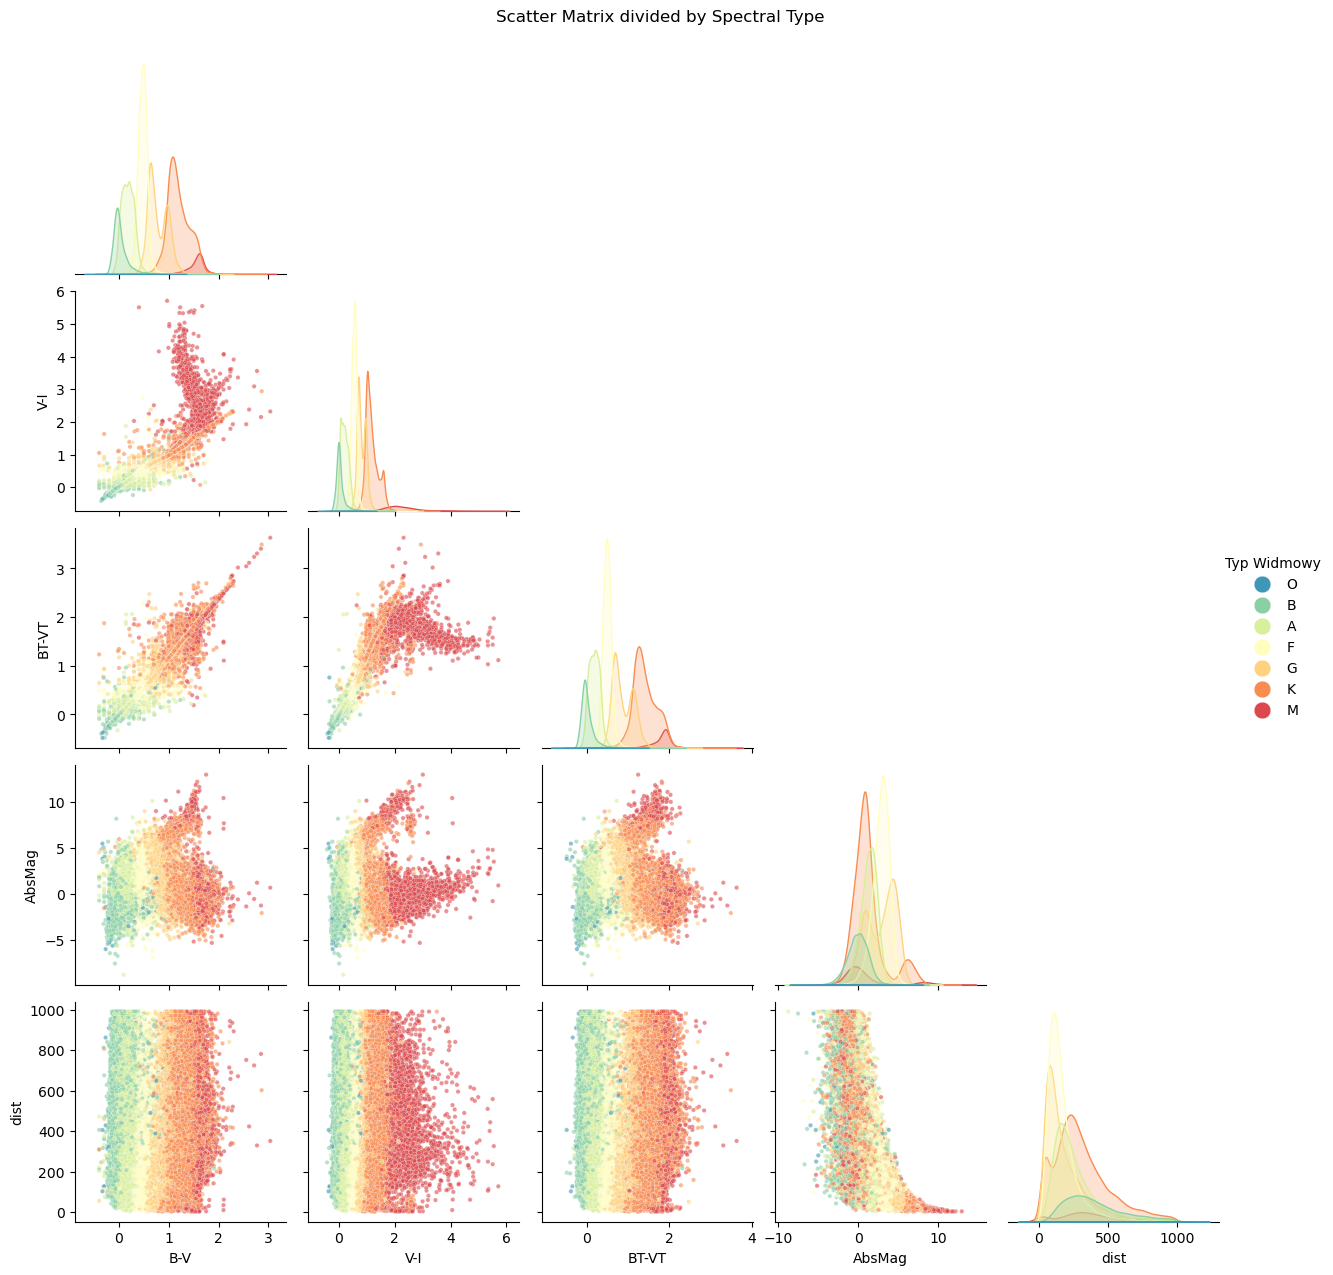

In [13]:
print(df["TargetClass"].value_counts())

g = sns.pairplot(
    df, 
    vars=["B-V", "V-I", "BT-VT", "AbsMag", "dist"], 
    hue='TargetClass', 
    hue_order=['O', 'B', 'A', 'F', 'G', 'K', 'M'],
    palette='Spectral_r',
    plot_kws={'alpha': 0.6, 's': 10}, # Przezroczystość i rozmiar punktów
    corner=True 
)

legend = g._legend

if legend:
    legend.set_title("Typ Widmowy")
    
    # Używamy właściwej nazwy atrybutu: legend_handles
    for handle in legend.legend_handles: 
        
        # Ustawiamy pełną widoczność
        handle.set_alpha(1.0)
        
        # Bezpieczne ustawianie rozmiaru (działa dla obu typów obiektów)
        try:
            handle.set_sizes([150])      # Dla PathCollection (kropki scattera)
        except AttributeError:
            handle.set_markersize(12)    # Dla Line2D (gdyby matplotlib tak to zinterpretował)

# Tytuł (trzeba przesunąć lekko w górę)
plt.suptitle("Scatter Matrix divided by Spectral Type", y=1.02)
plt.show()

We can see, that distance plots are much better. The distribution of colors don't depend on distance. Still we can se logharitm dependency of Absolute Magnitude, however it is much more blured (it is also depended from observed magnitude). Finally, the histogram of distance is much more better, however still a bit skew. We can also see a bit diffrent distribution of stars for different spectral type.

Let's look for correlation and basics statistics

          AbsMag     BT-VT       B-V       V-I
AbsMag  1.000000 -0.130445 -0.100797 -0.073847
BT-VT  -0.130445  1.000000  0.992009  0.931469
B-V    -0.100797  0.992009  1.000000  0.936717
V-I    -0.073847  0.931469  0.936717  1.000000
                Vmag            Plx          BTmag          VTmag  \
count  102768.000000  102768.000000  102768.000000  102768.000000   
mean        8.208176       7.415082       9.060486       8.283316   
std         1.206410       8.758717       1.355259       1.205610   
min        -0.620000       1.010000      -0.417000      -0.608000   
25%         7.550000       3.000000       8.284000       7.624000   
50%         8.330000       5.000000       9.199000       8.413000   
75%         9.000000       8.650000      10.001000       9.079000   
max        11.850000     310.750000      13.208000      12.058000   

                 B-V            V-I           dist         AbsMag  \
count  102768.000000  102768.000000  102768.000000  102768.000000   
mean 

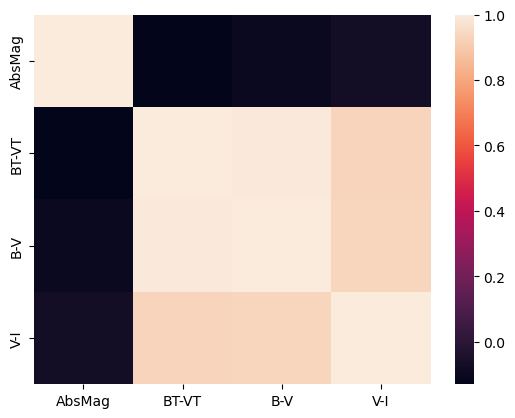

In [11]:
features = ["AbsMag","BT-VT", 'B-V', "V-I"]

corr = df[features].corr()

print(corr)

sns.heatmap(corr)

print(df.describe())

print(df["TargetClass"].value_counts())

grouped = df.groupby(by=df["TargetClass"])
print(grouped[["Vmag", "Plx", "BTmag", "VTmag", "dist","AbsMag",'B-V', "V-I", "BT-VT"]].mean())
print(grouped)

We can see, that Absolute Magnitude has no correletion with other variables, while color indicators has correlation near 1. It is expected behavior, becouse in mostly cases, if star is in the middle of color spectrum, the differencies between green and blue, and green and infrared will be similar. Whereas, B-V and BT-VT bands are very similar, and they are simply alternative bands. So high correletions are fine from scientific point of view.

C:\Users\Michał\AppData\Local\Temp\ipykernel_14368\2432245917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Michał\AppData\Local\Temp\ipykernel_14368\2432245917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Michał\AppData\Local\Temp\ipykernel_14368\2432245917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Michał\AppData\Local\Temp\ipykernel_14368\2432245917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

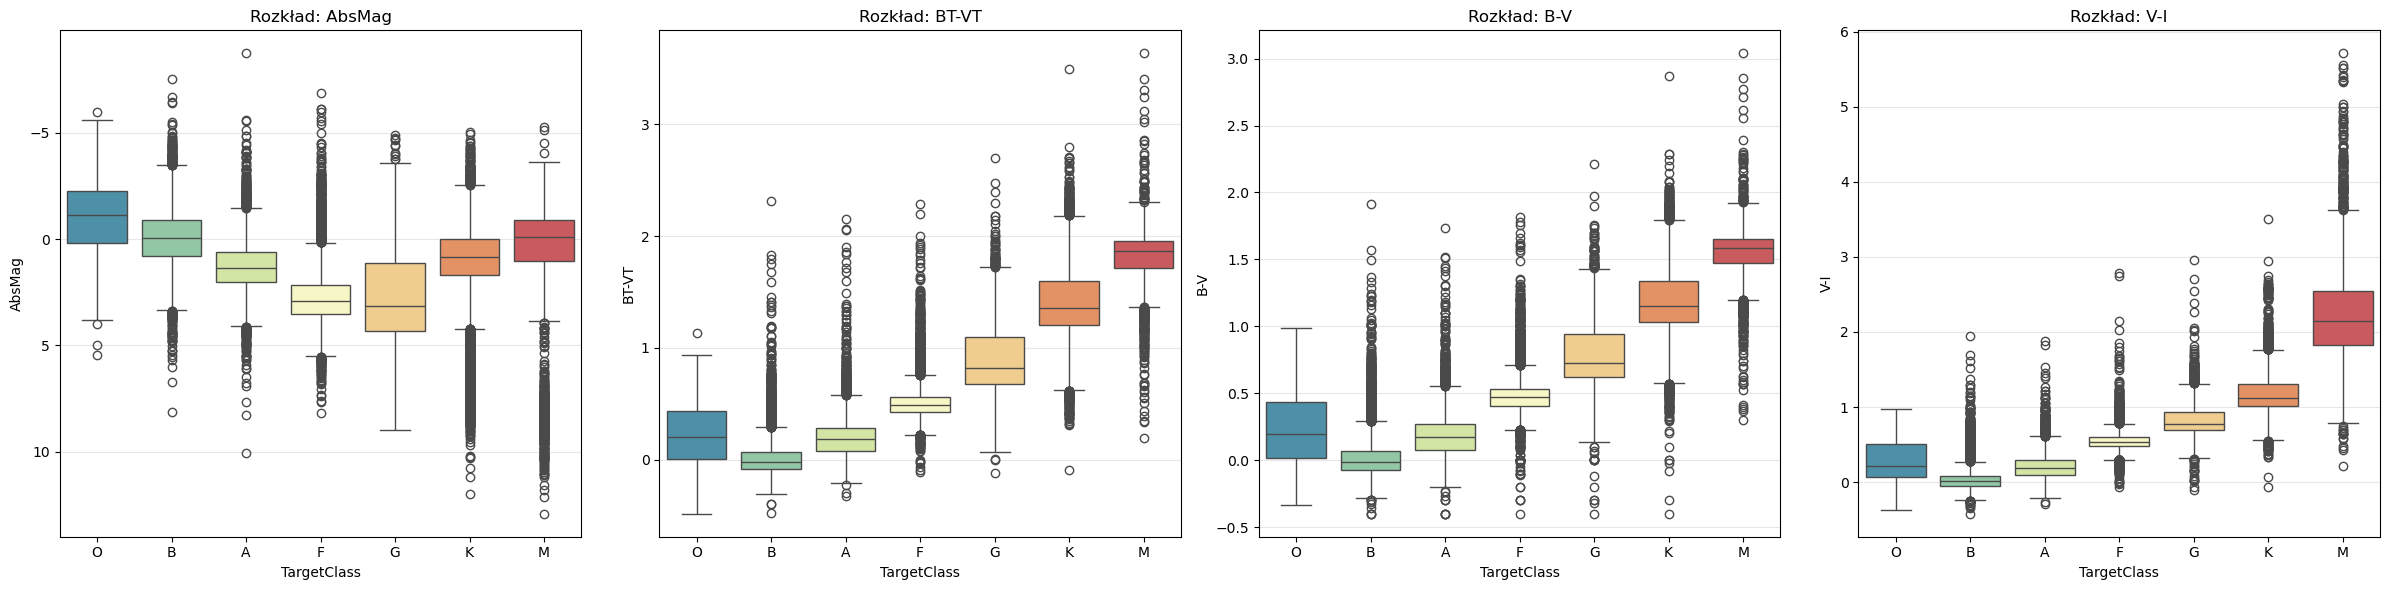

In [12]:
spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=df, 
        x='TargetClass', 
        y=feature, 
        order=spectral_order,  
        palette='Spectral_r', 
        ax=ax
    )
    
    ax.set_title(f'Rozkład: {feature}')
    ax.grid(True, alpha=0.3, axis='y')
    
    if feature == 'AbsMag':
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

At the end, we can encode spectral classes to numbers from 0 to 6. In this case it make sens, because classes are sorted by temperature, so class B is nearer to class O than M. 

In [13]:
spectral_mapping = {
    'O': 0, 
    'B': 1, 
    'A': 2, 
    'F': 3, 
    'G': 4, 
    'K': 5, 
    'M': 6
}

df['TargetEncoded'] = df['TargetClass'].map(spectral_mapping)

# Creaing train and test sets

In [14]:
model_df = df[["AbsMag", "B-V", "V-I", "BT-VT"]]
labels = df["TargetEncoded"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
  model_df, labels, test_size=0.2, random_state=2137, stratify=labels
)

print(y_train.value_counts())
print(y_test.value_counts())

TargetEncoded
5    22454
3    19611
4    17075
2    13863
1     6524
6     2604
0       83
Name: count, dtype: int64
TargetEncoded
5    5614
3    4903
4    4268
2    3466
1    1631
6     651
0      21
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [16]:
def confussion_heatmap(conf, method, ax=None):
  if ax is None:
        ax = plt.gca()
  
  plt.figure(figsize=(8, 6))
  sns.heatmap(
    conf, 
    annot=True,             
    fmt='d',              
    cmap='Blues',          
    xticklabels=['O', 'B', 'A', 'F', 'G', 'K', 'M'],
    yticklabels=['O', 'B', 'A', 'F', 'G', 'K', 'M'],
    ax=ax
  )
  ax.set_xlabel('predicted')
  ax.set_ylabel('actual')
  ax.set_title(f"Confussion heatmap - {method}")
  #plt.show()

# Trival classifier

Let's check F1 score for trival classifier in order to set reference level to which we will compare result from models. This classifier simply randomly assign type, with probabilities getting from empirical fractions. This method probably give the highest F1 score from dummy classifiers, because F1 macro score is sensitive for badly class assignments. Dummy giving all stars the most popular type or drawing them uniformly, can give lower reference level.

In [17]:
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="stratified", random_state=2137) #we want random draw type with probabilities according empirical probabilities in training set
dummy.fit(X_train, y_train)
dummy_predict = dummy.predict(X_test)

print(f"F1 for Dummy Classifier: {f1_score(y_true=y_test, y_pred=dummy_predict, average="macro")}")

F1 for Dummy Classifier: 0.1465025200484275


# Random trees & forest

F1 for Single Random Tree: 0.6963521037375932


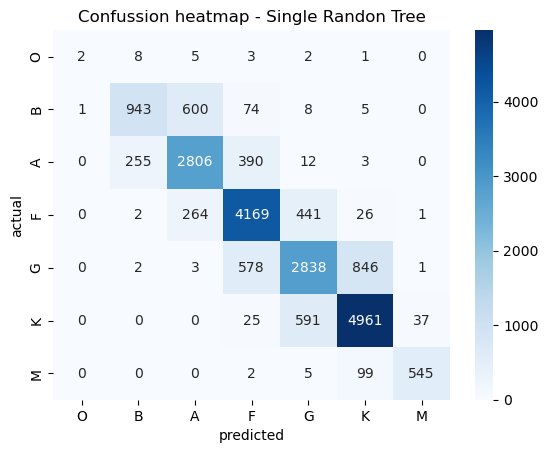

<Figure size 800x600 with 0 Axes>

In [21]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion="gini", random_state=2137, max_depth=8)
tree.fit(X_train, y_train)
tree_predict = tree.predict(X_test)

print(f"F1 for Single Random Tree: {f1_score(y_true=y_test, y_pred=tree_predict, average="macro")}")
conf_tree = confusion_matrix(y_true=y_test, y_pred=tree_predict)
confussion_heatmap(conf_tree, "Single Randon Tree")

F1 score almost 70% is quite high compared to refference level. Maximum depth of tree was choosen empiricaly. Without boundness F1 drops to 62%. Confusion matrix shows that mostly adjacent types are mistaken. Interesting thing happens for "O" type. Much higher number "O" type stars were assigned as colder types (esspecialy "B" and "A" type). Interesingly, setting `class_weight=balanced` cause decrease of F1 score. In that case tree assigned much more stars to "O" type, than it should.

F1 for Random Forest: 0.684275934569239


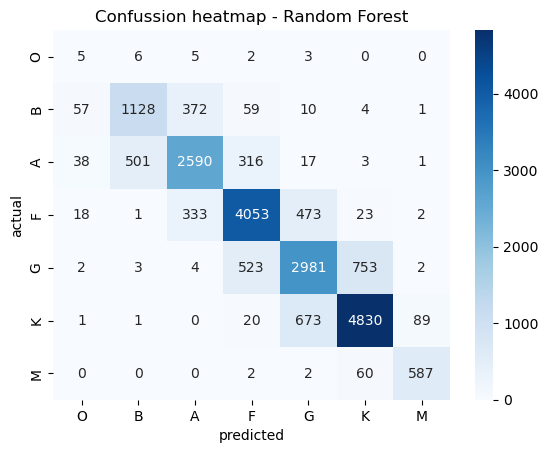

<Figure size 800x600 with 0 Axes>

In [22]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(criterion="gini", n_estimators=100, random_state=2137, n_jobs=-1, max_depth=8, class_weight="balanced_subsample")
forest.fit(X_train, y_train)
forest_predict = forest.predict(X_test)

print(f"F1 for Random Forest: {f1_score(y_true=y_test, y_pred=forest_predict, average="macro")}")
conf_forest = confusion_matrix(y_true=y_test, y_pred=forest_predict)
confussion_heatmap(conf_forest, "Random Forest")

Suprisingly, random forest after tunnig (setting `max_depth` same as single tree) give similar F1 score as single tree (even a bit lower). In this case setting `class_weight` as `balanced_subsample` gives better results. It is worth to note, that altough F1 score is lower, predictions for all types excluding "O", are more accurate, than for single decision tree. Only "O" type lowers F1 score. We can see, setting `class_weight = balanced_subsample` cause "O" type was assigned much more often, than without it (and it is totally expected).

# AdaBoost

F1 for AdaBoost: 0.6710219096231105


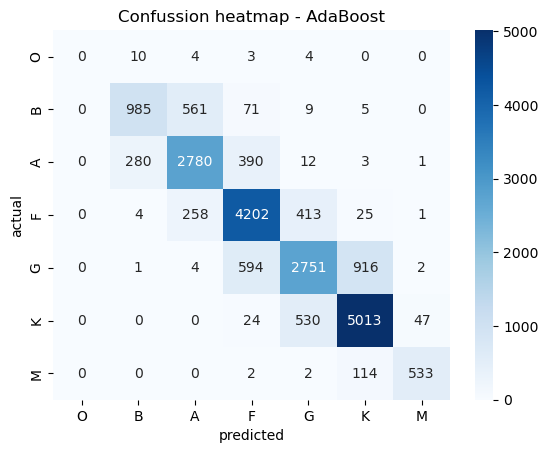

<Figure size 800x600 with 0 Axes>

In [23]:
from sklearn.ensemble import AdaBoostClassifier

base_tree = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=2137)
ada = AdaBoostClassifier(estimator=base_tree, n_estimators=100, learning_rate=0.05, random_state=2137)

ada.fit(X_train, y_train)
ada_predict = ada.predict(X_test)

print(f"F1 for AdaBoost: {f1_score(y_true=y_test, y_pred=ada_predict, average="macro")}")
conf_ada = confusion_matrix(y_true=y_test, y_pred=ada_predict)
confussion_heatmap(conf_ada, "AdaBoost")

AdaBoost reach similar results as other methods. By experimenting I chose the best hiperparameters. For shallow trees (depht=1) it gives bad results (below 50%). Optimal depth of tree is about 4 (deeper have same F1). Increasing n_estimators don't give better results (even they are worse), and learning rate is also optimal.

# XGBoost

F1 for XGBoost: 0.6774118606342482


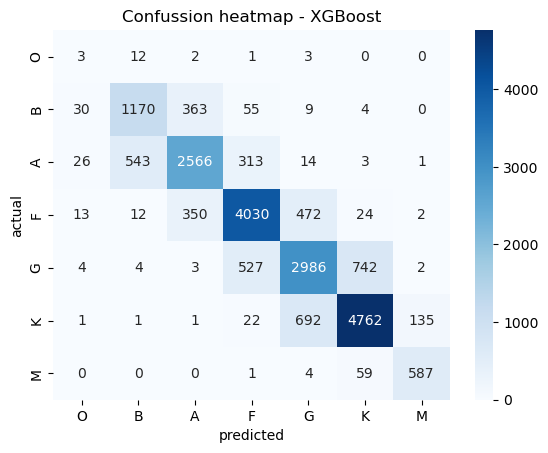

<Figure size 800x600 with 0 Axes>

In [42]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=7,
    tree_method='hist',
    random_state=2137
)

xgb_model.fit(X_train, y_train, sample_weight=weights)

xgb_pred = xgb_model.predict(X_test)

print(f"F1 for XGBoost: {f1_score(y_true=y_test, y_pred=xgb_pred, average="macro")}")
conf_xgb = confusion_matrix(y_true=y_test, y_pred=xgb_pred)
confussion_heatmap(conf_xgb, f"XGBoost")

I started with parameters:
`n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=7,
    tree_method='hist',
    random_state=2137`
and got similar results as for ADABoost, both in F1 score or in confusion matrix. Then I tried add weights, however it didn't help too much. Then I tried make random search fot best parameters, and still don't get better results.

In [43]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [1, 1.5, 2]
}

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=7, tree_method='hist')

# RandomizedSearch sprawdzi np. 20 losowych kombinacji z tej siatki
random_search = RandomizedSearchCV(
    xgb_model, 
    param_distributions=param_dist, 
    n_iter=20, 
    scoring='f1_macro', 
    cv=3, 
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train, sample_weight=weights)
print(f"Najlepsze parametry: {random_search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Najlepsze parametry: {'subsample': 0.9, 'reg_lambda': 1.5, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}


F1 for best XGBoost: 0.6657669929828441


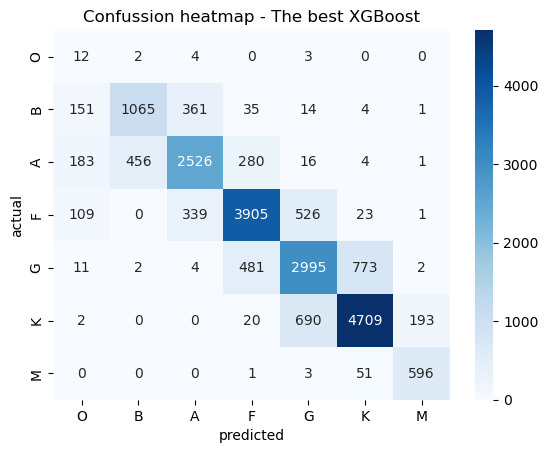

<Figure size 800x600 with 0 Axes>

In [44]:
xgb_model_2 = xgb.XGBClassifier(
    subsample = 0.9,
    reg_lambda = 1.5,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    objective='multi:softmax',
    num_class=7,
    tree_method='hist',
    gamma = 0.1,
    colsample_bytree = 0.7,
    random_state=2137
)

xgb_model_2.fit(X_train, y_train, sample_weight=weights)

xgb_pred_2 = xgb_model_2.predict(X_test)

print(f"F1 for best XGBoost: {f1_score(y_true=y_test, y_pred=xgb_pred_2, average="macro")}")
conf_xgb_2 = confusion_matrix(y_true=y_test, y_pred=xgb_pred_2)
confussion_heatmap(conf_xgb_2, f"The best XGBoost")

# Catboost

0:	learn: 1.8508602	total: 46.8ms	remaining: 46.7s
100:	learn: 0.6368420	total: 4.28s	remaining: 38.1s
200:	learn: 0.5704552	total: 8.02s	remaining: 31.9s
300:	learn: 0.5432964	total: 11.7s	remaining: 27.2s
400:	learn: 0.5218105	total: 15.4s	remaining: 22.9s
500:	learn: 0.4982068	total: 18.7s	remaining: 18.7s
600:	learn: 0.4829914	total: 22.1s	remaining: 14.6s
700:	learn: 0.4721736	total: 25.4s	remaining: 10.8s
800:	learn: 0.4642210	total: 28.8s	remaining: 7.14s
900:	learn: 0.4581963	total: 32s	remaining: 3.51s
999:	learn: 0.4528231	total: 35.4s	remaining: 0us
F1 for best CatBoost: 0.6764906379313701


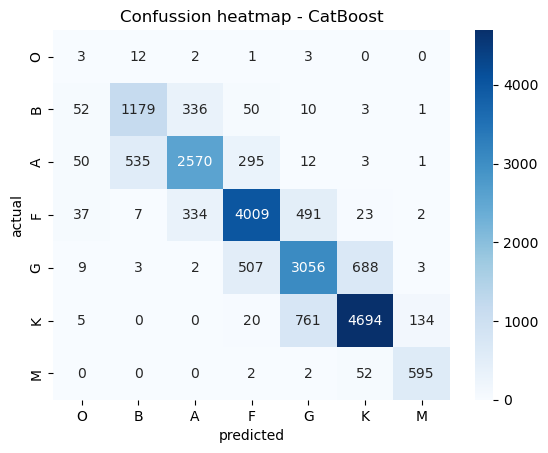

<Figure size 800x600 with 0 Axes>

In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    loss_function='MultiClass',
    random_seed=2137,
    verbose=100
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

print(f"F1 for best CatBoost: {f1_score(y_true=y_test, y_pred=cat_pred, average="macro")}")
conf_cat = confusion_matrix(y_true=y_test, y_pred=cat_pred)
confussion_heatmap(conf_cat, f"CatBoost")

As we can see, CatBoost also reach F1 score 67%. So it looks like, there is no way to seperate O stars and B stars well. However in other categories it performs quite good results.

# KNN

Here we use GridSearch which try all parameters from given grid of parameters.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
The best parameters: {'metric': 'manhattan', 'n_neighbors': 81, 'weights': 'uniform'}
F1 for the best KNN: 0.6719118667224443


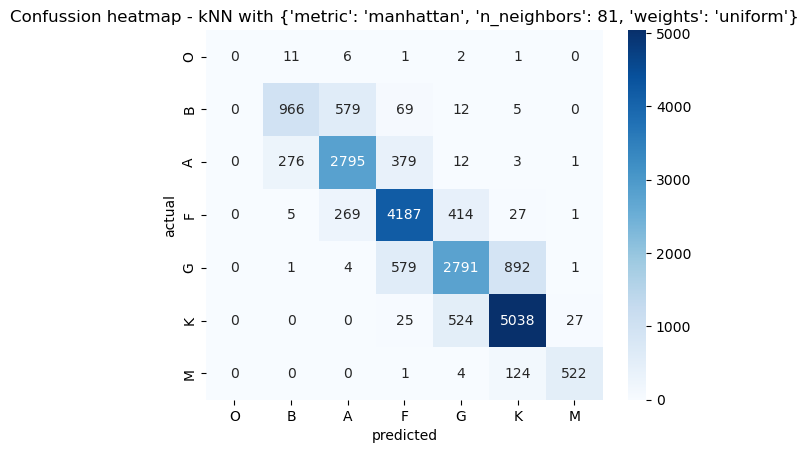

<Figure size 800x600 with 0 Axes>

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 11, 21, 41, 81],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_std, y_train)

print(f"The best parameters: {grid_search.best_params_}")

best_knn = grid_search.best_estimator_
knn_pred = best_knn.predict(X_test_std)

print(f"F1 for the best KNN: {f1_score(y_true=y_test, y_pred=knn_pred, average="macro")}")
conf_knn = confusion_matrix(y_true=y_test, y_pred=knn_pred)
confussion_heatmap(conf_knn, f"kNN with {grid_search.best_params_}")


As we can see, the best method (with manhattan metric, k=81 and weights=uniform), is quite good for all types excluding "O" type. It is expected, because in training set we have only 83 "O" stars, so it is quite challenging for them to be the most frequent. As we can see, this model doesn't predict any "O" star. Let's try same model with weights=distance (it puts more weight on nearer point). Because this model didn't win in previous step, we expect, it will be lower F1 score, so probably it will predict worse for other classes.

F1 for KNN, k=81, metric=manhattan, weights=distance: 0.6694833277366856


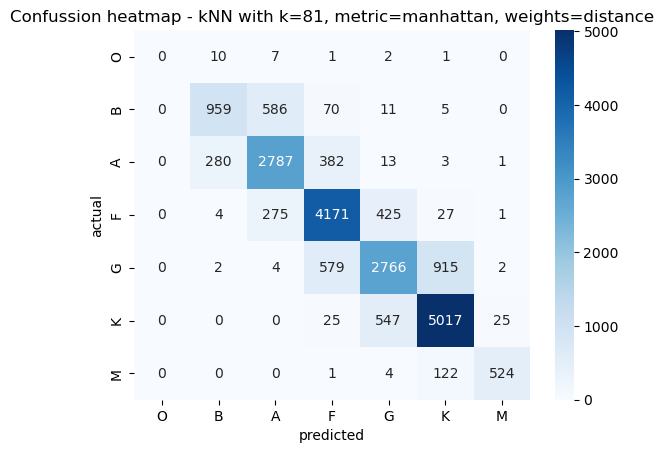

<Figure size 800x600 with 0 Axes>

In [25]:
knn_2 = KNeighborsClassifier(n_neighbors=81, weights="distance", metric="manhattan")
knn_2.fit(X_train_std, y_train)
knn_2_pred = knn_2.predict(X_test_std)

print(f"F1 for KNN, k=81, metric=manhattan, weights=distance: {f1_score(y_true=y_test, y_pred=knn_2_pred, average="macro")}")
conf_knn_2 = confusion_matrix(y_true=y_test, y_pred=knn_2_pred)
confussion_heatmap(conf_knn_2, "kNN with k=81, metric=manhattan, weights=distance")

Weighting by distances didn't help for "O" types. Still, model doesn't predict any "O" type. Let's try using higher values for k, 81 was upper boundary, so maybe optimal value will be higher.

Fitting 5 folds for each of 5 candidates, totalling 25 fits
The best parameters: {'metric': 'manhattan', 'n_neighbors': 81, 'weights': 'uniform'}
F1 for the 3rd attempt of kNN: 0.6719118667224443


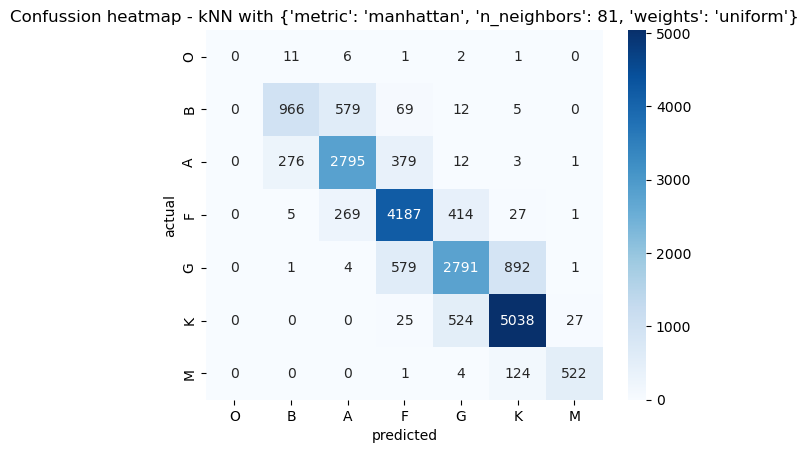

<Figure size 800x600 with 0 Axes>

In [26]:
knn_3 = KNeighborsClassifier()

param_grid_2 = {
    'n_neighbors': [81, 101, 151, 201, 301],
    'weights': ['uniform'],
    'metric': ['manhattan']
}

grid_search_2 = GridSearchCV(
    estimator=knn_3,
    param_grid=param_grid_2,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_2.fit(X_train_std, y_train)

print(f"The best parameters: {grid_search_2.best_params_}")

best_knn_2 = grid_search_2.best_estimator_
knn_3_pred = best_knn_2.predict(X_test_std)

print(f"F1 for the 3rd attempt of kNN: {f1_score(y_true=y_test, y_pred=knn_3_pred, average="macro")}")
conf_knn_3 = confusion_matrix(y_true=y_test, y_pred=knn_3_pred)
confussion_heatmap(conf_knn_3, f"kNN with {grid_search_2.best_params_}")

As we can see, optimal value is about 81. Probably for higher values model takes too much neighboors, and predict only the most frequent types.

# Multiclass logisic regression

In [27]:
from sklearn.linear_model import LogisticRegression

def make_logistic_reg(*indexes):
  #In indexes write:
  # 0 if you want AbsMag
  # 1 if you want B-V
  # 2 if you want V-I
  # 3 if you want BT-VT

  model = LogisticRegression(
    C = 100,
    random_state=2137,
    solver="lbfgs",
    class_weight="balanced", #bc classes are unbalanced
    max_iter=10000
  )
  
  indexes = list(indexes)# + [0]
  X_train_log = X_train_std[:,indexes]
  X_test_log = X_test_std[:,indexes]

  model.fit(X_train_log, y_train)

  y_pred = model.predict(X_test_log)

  names_dict = {
    0: "AbsMag",
    1: "B-V",
    2: "BT-VT",
    3: "V-I"
  }

  names = [names_dict[number] for number in indexes]
  print(f"F1 for {names}: {f1_score(y_true=y_test, y_pred=y_pred, average="macro")}")

  conf_log = confusion_matrix(y_true=y_test, y_pred=y_pred)
  #print(conf_log)
  return([model, y_pred, conf_log])

## models without AbsMag

Let's check how works models only with color variables. It is easier to get only colors (to get Absolute Magnitude you must measure Observable Magnitude and Paralax)

### B-V, BT-VT, V-I

F1 for ['B-V']: 0.5237014995025817
F1 for ['BT-VT']: 0.5711267897020859
F1 for ['V-I']: 0.517617709535661


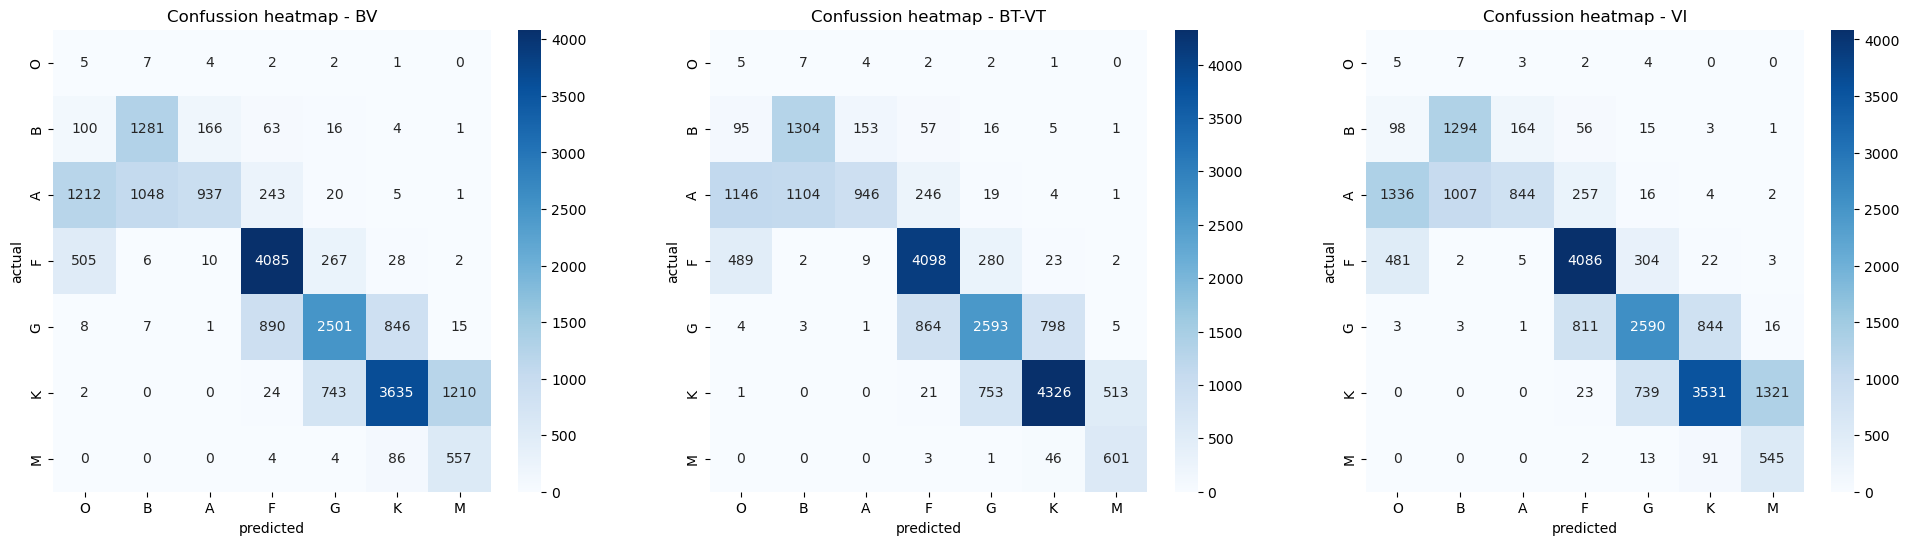

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [28]:
model_BV, pred_BV, conf_BV = make_logistic_reg(1)
model_BTVT, pred_BTVT, conf_BTVT = make_logistic_reg(2)
model_VI, pred_VI, conf_VI = make_logistic_reg(3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

confussion_heatmap(conf_BV, "BV", ax1)
confussion_heatmap(conf_BTVT, "BT-VT", ax2)
confussion_heatmap(conf_VI, "VI", ax3)

plt.show()

F1 score for simple models with only one color is in the middle. It is noticably higher than dummy classifier, but lower than random trees. It is worth to note, that for BT-VT band this score is higher than others (57% compared to about 52% for others). Confusion matrixes shows, that this model is terrible for predicting "O" type (super hot blue giants). In "B" it is also not well, however for colder stars (type "A" and further), these models are not so bad. We can see, that mostly are mistaken stars with adjacent types.

### B-V + V-I, BT-VT + V-I

F1 for ['B-V', 'V-I']: 0.5678531837612122
F1 for ['BT-VT', 'V-I']: 0.6424673538093363


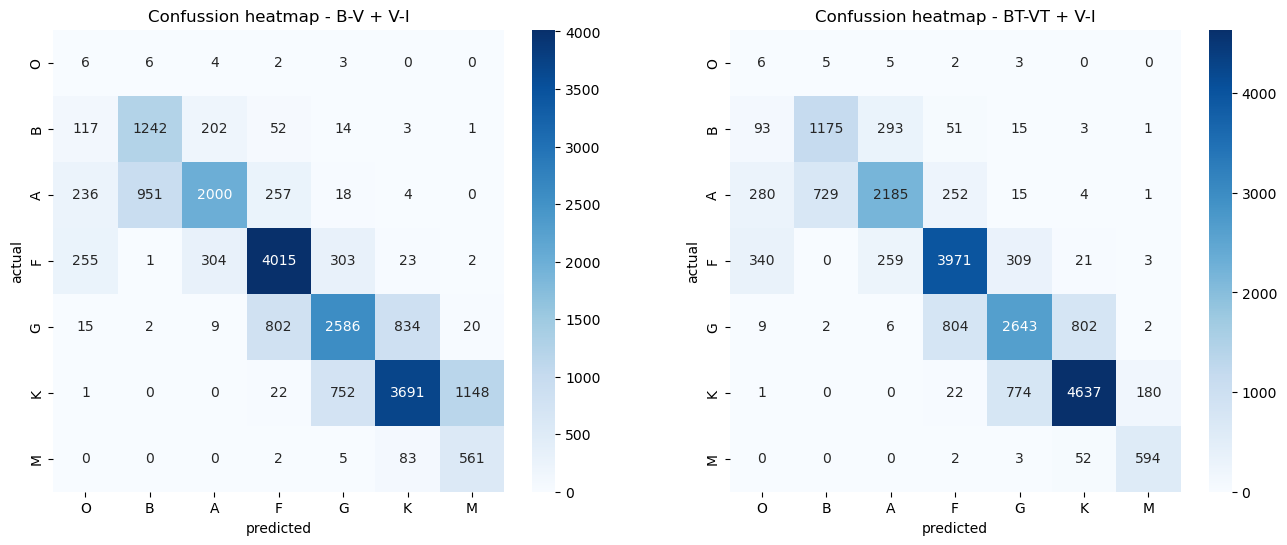

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [29]:
model_BVI, pred_BVI, conf_BVI = make_logistic_reg(1,3)
model_BTVI, pred_BTVI, conf_BTVI = make_logistic_reg(2,3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

confussion_heatmap(conf_BVI, "B-V + V-I", ax1)
confussion_heatmap(conf_BTVI, "BT-VT + V-I", ax2)

plt.show()

Two dimensional models are better, than one. The better one is model with BT-VT band (Tycho probe) (64% compared to 57% for Hipparcos (B-V) probe). Confussion matrices also shows improvment (in particular in hot types). These models are only bad for "O" type, not terrible.

### B-V + V-I + BT-VT

F1 for ['B-V', 'BT-VT', 'V-I']: 0.6431118101575775


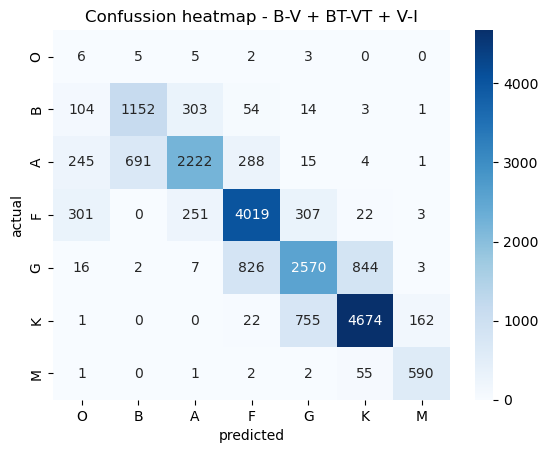

<Figure size 800x600 with 0 Axes>

In [30]:
model_all_col, pred_all_col, conf_all_col = make_logistic_reg(1,2,3)

confussion_heatmap(conf_all_col, "B-V + BT-VT + V-I")

plt.show()

Model with all color vairables has almost the same F1 score as model with BT-VT + V-I. Confusion matrix shows that this model make similar mistakes that two 2-dimensional models, moreover, for "O" type is a bit worse. This result it is not suprising, because B-V and BT-VT are almost the same parameters, and toghether they cannot improve model (even they can weaken model). Simplicity is better, so the best model based only for color measurments is BT-VT + VI.

## Models with Absolute Magnitude

### B-V/BT-VT/V-I + AbsMag

F1 for ['AbsMag', 'B-V']: 0.5809220470089824
F1 for ['AbsMag', 'BT-VT']: 0.633412714047053
F1 for ['AbsMag', 'V-I']: 0.5751933516635624


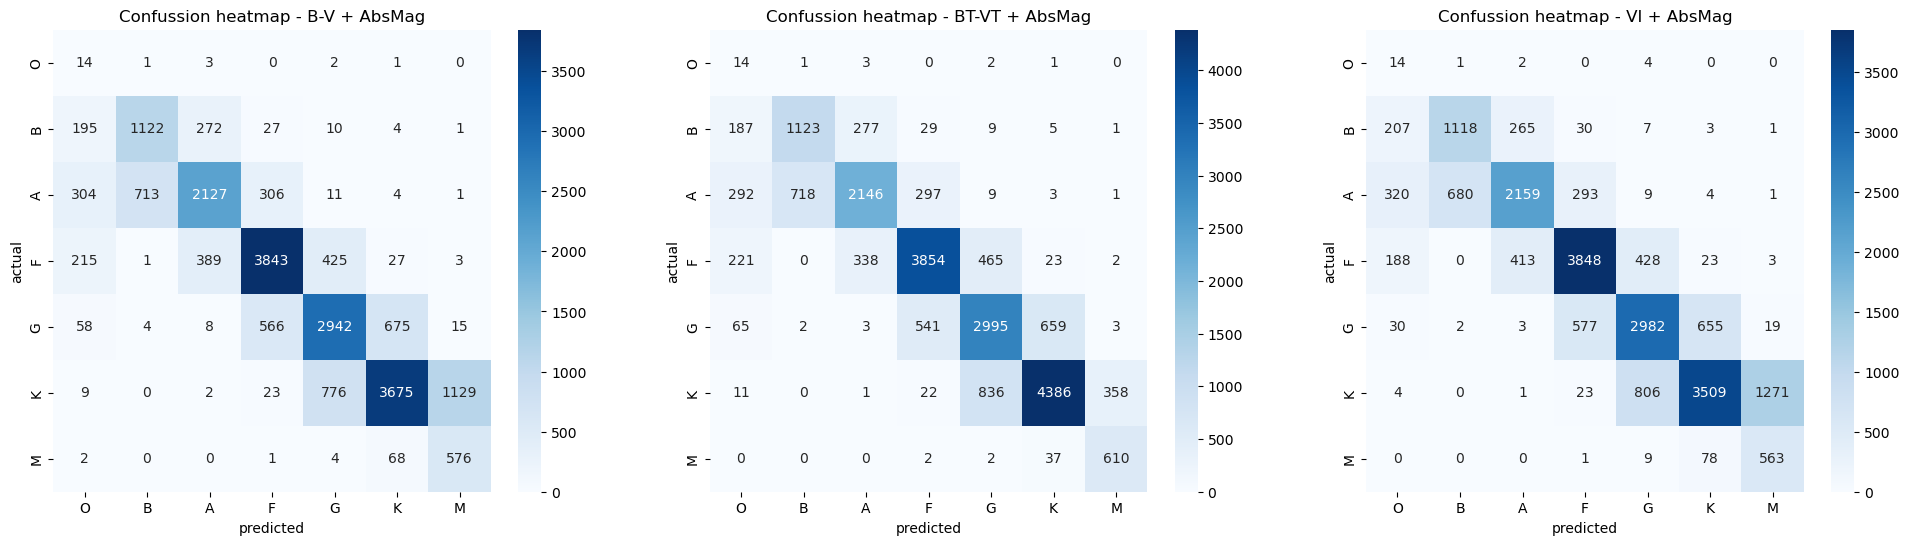

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [31]:
model_magBV, pred_magBV, conf_magBV = make_logistic_reg(0,1)
model_magBTVT, pred_magBTVT, conf_magBTVT = make_logistic_reg(0,2)
model_magVI, pred_magVI, conf_magVI = make_logistic_reg(0,3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

confussion_heatmap(conf_magBV, "B-V + AbsMag", ax1)
confussion_heatmap(conf_magBTVT, "BT-VT + AbsMag", ax2)
confussion_heatmap(conf_magVI, "VI + AbsMag", ax3)

plt.show()

The performences of models with one color and AbsModel are better than models without AbsMag. The model with BT-VT band stands out, it has almost the same F1 score as the best model with only colors. Confusion matrices show that models are not so bad. Classicaly they have poor quality for super hot and cold types. 
Surprisingly, V-I band don't deal well with red types (as "M"), while it should deal better than bands with shorter lenght of wave.

### B-V/BT-VT + V-I + AbsMag

F1 for ['AbsMag', 'B-V', 'V-I']: 0.5882596933727765
F1 for ['AbsMag', 'BT-VT', 'V-I']: 0.6526079149419833


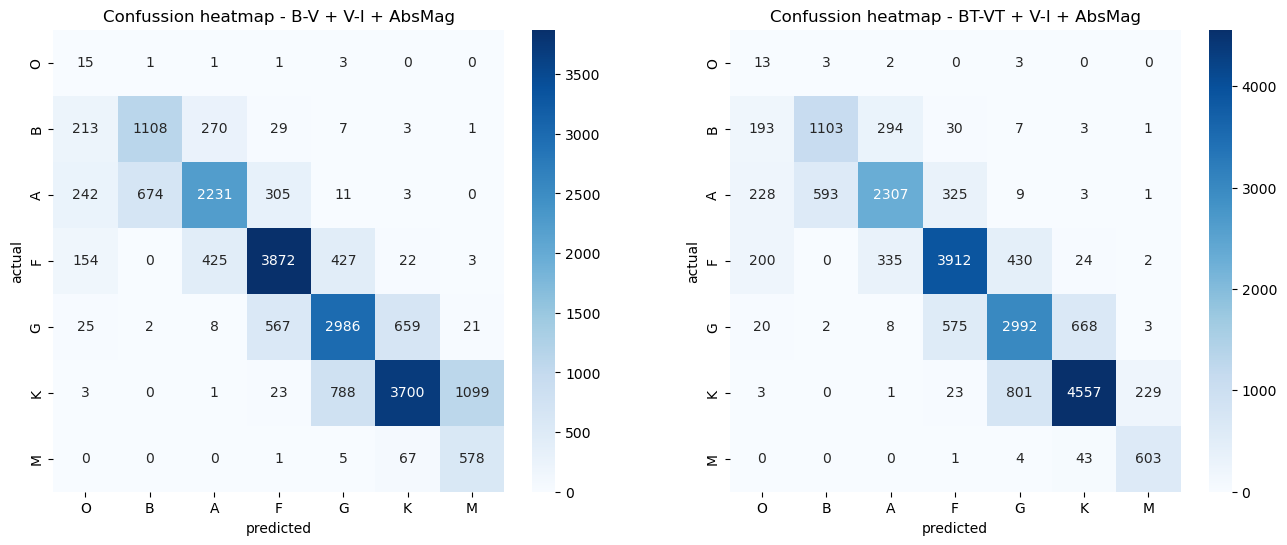

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [32]:
model_magBVI, pred_magBVI, conf_magBVI = make_logistic_reg(0,1,3)
model_magBTVI, pred_magBTVI, conf_magBTVI = make_logistic_reg(0,2,3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

confussion_heatmap(conf_magBVI, "B-V + V-I + AbsMag", ax1)
confussion_heatmap(conf_magBTVI, "BT-VT + V-I + AbsMag", ax2)

plt.show()

Adding V-I band to models with shorter wave lenght, doesn't improve models too much. Model B-V + V-I has almost the same F1 score as models with only B-V and V-I, while BT-VT + V-I is better by 2 percentage points. However the score 65% is the best at this point. Model B-V + V-I still has poor quality for cold, red types (as "M"). However in both models the characters of errors are similar as 1-dimensional models. It is worth to note, that model BT-VT + V-I is a bit better for super hot stars ("O" and "B" types).

### Model with all variables

F1 for ['AbsMag', 'B-V', 'BT-VT', 'V-I']: 0.6553467377422237


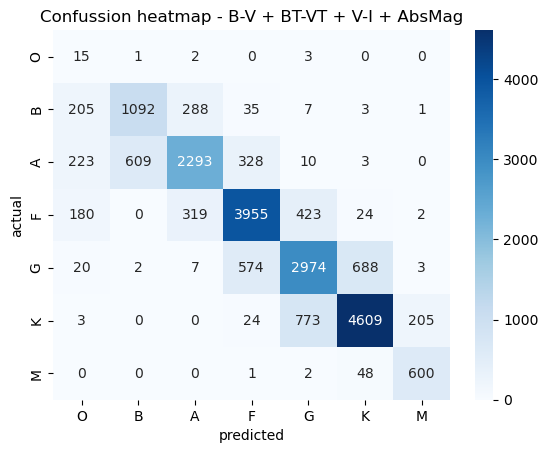

<Figure size 800x600 with 0 Axes>

In [33]:
model_all, pred_all, conf_all = make_logistic_reg(0,1,2,3)

confussion_heatmap(conf_all, "B-V + BT-VT + V-I + AbsMag")

plt.show()

Similary as in the case without Absolute Magnitude, model with all variables has almost the same F1 score, and confusion matrix, as the best model with 2 color variables. The reasons are the same as in that case: B-V and BT-VT are almost (this "almost" make difference between models with smaller number of variables) the same. In super hot types this model is a bit weaker that BT-VT + VI.

So, the best models with linear logistic regression are BT-VT + VI (with 63% F1 score), and BT-VT + V-I + AbsMag (with 65% F1 score). Still, this result is a bit low. At the end, let's see how decision boundaries looks for the best models. To visualize it, I will use plots with 

# Neural network

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

{0: 141.50430292598966,
 1: 1.8002540071822721,
 2: 0.8472089116971178,
 3: 0.5988912927875755,
 4: 0.6878393641497594,
 5: 0.5230630240873405,
 6: 4.510313802940531}

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_std, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6699 - loss: 0.9112 - val_accuracy: 0.6860 - val_loss: 0.7803
Epoch 2/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7103 - loss: 0.7851 - val_accuracy: 0.7520 - val_loss: 0.6615
Epoch 3/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7260 - loss: 0.7635 - val_accuracy: 0.7552 - val_loss: 0.6636
Epoch 4/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7328 - loss: 0.7491 - val_accuracy: 0.7556 - val_loss: 0.6416
Epoch 5/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7382 - loss: 0.7220 - val_accuracy: 0.7528 - val_loss: 0.6391
Epoch 6/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7417 - loss: 0.7016 - val_accuracy: 0.7609 - val_loss: 0.6253
Epoch 7/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7379 - loss: 0.7128 - val_accuracy: 0.7550 - val_loss: 0.6688
Epoch 8/100
2056/2056 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7414 -

643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
F1 for the Neural Network: 0.6751503321455486


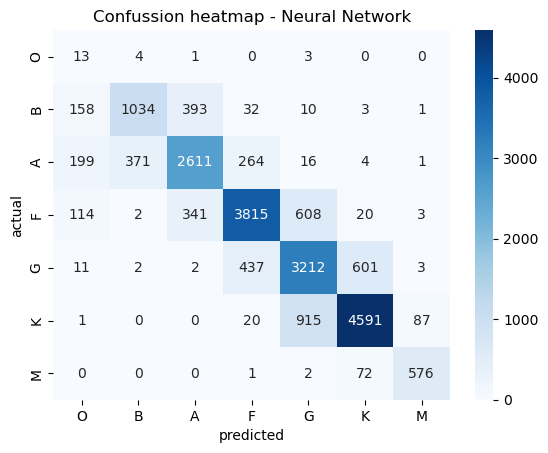

<Figure size 800x600 with 0 Axes>

In [35]:
pred_net = np.argmax(model.predict(X_test_std), axis=1)

print(f"F1 for the Neural Network: {f1_score(y_true=y_test, y_pred=pred_net, average="macro")}")
conf_net = confusion_matrix(y_true=y_test, y_pred=pred_net)
confussion_heatmap(conf_net, f"Neural Network")

# Conclusions

As we can see, the best results gives surprisingly single decision tree. It performs F1 score almost 70%. It looks like, this level is the glass ceiling for all sophisticated models. The reason for this is most probably the fact, that there is very little amount of "O" stars (only 21 in test size, vs. about 5500 in "K" type) and this type is quite "spreaded" across other types (the most, adjacent class: "B"). This cause two efects for models. One way is completly ignoring this stars (or almost ignoring), which cause very little recall, but very high precision. The second way is saying too most that the star is "O", causing very high number of predicted "O" stars (much more than in was in test set). In that case there is very high precision and very small recal. The nearest ones to balanced this two ways were Random Forest, and XGBoost. However XGBoost didn't predict too much "O" stars, which were really "O" stars. So, to solve this problem there is probably needed additional variables, which weren't in the dataset.